In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  

path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

plt.rcParams['text.usetex'] = True
def select_region3D(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1]),
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region

path_folder = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
exp_folder_name = "RT42_sst_0_bucket"
path = f"{path_folder}/{exp_folder_name}"
ds_age_ = xr.open_dataset(f"{path}/age.nc")
#ds_age_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_/age.nc")
ds_dyn_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_bucket/dynamics.nc")
ds_pre_ = xr.open_dataset(f"{path_folder}/RT42_sst_0_bucket/age.nc")
path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

In [2]:
ds_age = select_region3D(ds_age_, (-90,90), (0,360), (0,1000))  
ds_dyn = select_region3D(ds_dyn_, (-90,90), (0,360), (0,1000))  
ds_pre = select_region3D(ds_pre_, (-90,90), (0,360), (0,1000)) 


q = ds_age.sphum
sphum = ds_age.sphum

P = ds_age.precipitation.values
ps = ds_age.ps
area = dps.get_area(ds_age)
phalf = 100*ds_age.phalf.values
sink = ds_age.dt_sink.mean("time").values
seconds_per_day = np.float32(24 * 60 * 60)
mean_age_ = (ds_age.sphum_age_1/q)
mom2_age = (ds_age.sphum_age_2/q)

std = np.sqrt(mom2_age.values - mean_age_.values**2)/seconds_per_day

mean_age = mean_age_.copy()
time_mean_age = mean_age.mean("time").values/ seconds_per_day
time_mom2_age = mom2_age.mean("time").values/ seconds_per_day**2
mom3_age = 0#(ds_age.sphum_age_3/q)
mom4_age = 0#(ds_age.sphum_age_4/q)
mom5_age = 0#(ds_age.sphum_age_5/q)


zonal_moments = np.array([
    mean_age.mean(dim=["time", "lon"]).values / seconds_per_day,
    mom2_age.mean(dim=["time", "lon"]).values / seconds_per_day**2,
    #mom3_age.mean(dim=["time", "lon"]).values / seconds_per_day**3,
    #mom4_age.mean(dim=["time", "lon"]).values / seconds_per_day**4,
])

    
ps = ds_age.ps
pfull = ds_age.pfull
phalf = ds_age.phalf.values
lat = ds_age.lat
lon = ds_age.lon


pfull = ds_age.pfull.values
latind = [int((0+90)*64/180),int((0+90)*64/180),int((0+90)*64/180),int((55+90)*64/180),int((55+90)*64/180),int((55+90)*64/180),int((82+90)*64/180),int((82+90)*64/180),int((82+90)*64/180)]
pg = [925,700,400,925,700,400,925,700,400]
pval = []
pinds = []
lats = [0,0,0,55,55,55,82,82,82]
j=0
for l in lats:
    i,p = dps.get_p_ind(pg[j],pfull)
    pval.append(p)
    pinds.append(i)
    j+=1

/tmp/ipykernel_2624768/2015216030.py:18: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(mom2_age.values - mean_age_.values**2)/seconds_per_day


In [3]:
from scipy.special import gamma
from math import prod

def gamma_dist(x,mean,mom2):
    if mean <= 0 or mom2 <= mean**2:
        return np.zeros_like(x)
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    num = x**(alpha -1) * np.exp(-x/theta)
    den = gamma(alpha) * theta**alpha
    res = num/den
    return res/np.sum(res)

def weibull_dist(x,mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return (b_/a_)*(x/a_)**(b_-1)*np.exp(-(x/a_)**b_)

def get_alpha_theta(mean,mom2):
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    return alpha, theta

def get_a_b(mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return a_, b_

def get_n_moment_weib(a,b,n):
    return a**n * gamma(1 + (n/b))

def get_n_moment_gamma(alpha, theta):
    mu_1 = alpha * theta
    mu_2 = alpha * (1 + alpha) * theta**2
    mu_3 = alpha*(alpha+1)*(alpha+2)*theta**3
    return mu_1, mu_2, mu_3


In [4]:
blues = [
    'solid',
    'dashed',
    'dotted',
    'solid',
    'dashed',
    'dotted',
    'solid',
    "dashed",
    'dotted'
]
colors = [
    'royalblue',
    'royalblue',
    'darkgreen',
    'darkgreen',
    'darkorange',
    'darkorange'
]


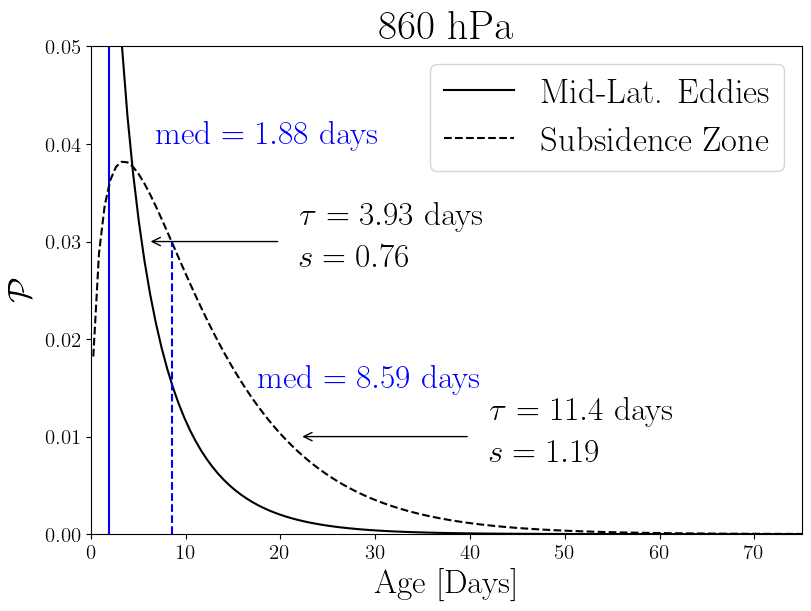

In [5]:
fig,ax = plt.subplots(1,1,figsize = (8,6),constrained_layout=True)
time = np.linspace(0.25,3000,5000)
dt = time[1] - time[0]
p = -6
lo = -25
la = 43

ax.set_ylim(0,0.05)
ax.set_xlim(0,75)
ax.set_ylabel(r"$\mathcal{P}$",fontsize = 24)
ax.set_xlabel("Age [Days]",fontsize = 24)
ax.set_title(f"860 hPa",fontsize = 30)

dist = gamma_dist(time,time_mean_age[p,lo,la],time_mom2_age[p,lo,la])
cdf = np.cumsum(dist)*dt
cdf /= cdf[-1] 
idd = np.argmin(np.abs(cdf-0.5))
med = np.interp(0.5, cdf, time)

ax.plot(time,dist,label = "Mid-Lat. Eddies",color = "black",linestyle = "solid")

ax.legend(fontsize = 25)
fig.savefig(f"{path_cur}/brace/sample_distribution_trop1.png",dpi = 250,bbox_inches = "tight")

ax.annotate("", xytext=(20, 0.03), xy=(6, 0.03),arrowprops=dict(arrowstyle="->"))
ax.text(22,0.0275,"$\\tau = 3.93$ days \n $s = 0.76$",fontsize = 24,linespacing=1.5)
fig.savefig(f"{path_cur}/brace/sample_distribution_trop2.png",dpi = 250,bbox_inches = "tight")

ax.vlines(med,0,0.09,color = "blue",linestyle = "solid")
ax.text(med+5,0.04,"med $ = 1.88$ days",fontsize = 24,linespacing=1.5,color = "blue")
fig.savefig(f"{path_cur}/brace/sample_distribution_trop3.png",dpi = 250,bbox_inches = "tight")


p = -6

lo = -2
la = 28

dist1 = gamma_dist(time,time_mean_age[p,lo,la],time_mom2_age[p,lo,la])
cdf1 = np.cumsum(dist1)*dt
cdf1 /= cdf1[-1] 
idd1 = np.argmin(np.abs(cdf1-0.5))
med1 = np.interp(0.5, cdf1, time)
ax.plot(time,dist1,label = "Subsidence Zone",color = "black",linestyle = "dashed")
ax.legend(fontsize = 25)
fig.savefig(f"{path_cur}/brace/sample_distribution_trop4.png",dpi = 250,bbox_inches = "tight")


ax.annotate("", xytext=(40, 0.01), xy=(22, 0.01),arrowprops=dict(arrowstyle="->"))
ax.text(42,0.0075,"$\\tau = 11.4$ days \n $s = 1.19$",fontsize = 24,linespacing=1.5)
fig.savefig(f"{path_cur}/brace/sample_distribution_trop5.png",dpi = 250,bbox_inches = "tight")


ax.vlines(med1,0,0.03,color = "blue",linestyle = "dashed")
ax.text(med1+9,0.015,"med $ = 8.59$ days",fontsize = 24,linespacing=1.5,color = "blue")
fig.savefig(f"{path_cur}/brace/sample_distribution_trop6.png",dpi = 250,bbox_inches = "tight")


#ax.text(2150,0.0004,"BDC timescale \n $\\sim 1.6$ yrs",fontsize = 24,linespacing=1.5,color = "blue")

fig.savefig(f"{path_cur}/brace/sample_distribution_trop7.png",dpi = 250,bbox_inches = "tight")

In [6]:
ds_precip_age = xr.open_dataset(f"{path}/precipitation_age.nc")
da = ds_precip_age.precip_age
masked = da.where(da != 0)
precip_age = masked.mean(dim="time", skipna=True)

In [7]:
precip_age.values[la,lo]/(24*60**2)
time_mom2_age.shape

(45, 64, 128)

In [8]:
profile = time_mean_age[:,la,lo]
momprofile = time_mom2_age[:,la,lo]
sinkprofile = sink[:,la,lo]
qprofile = ds_age.sphum.mean("time").values[:,la,lo]/(24*60**2)
profile_std = np.sqrt(time_mom2_age[:,la,lo]-time_mean_age[:,la,lo]**2)
profile.shape

(45,)

In [9]:
pfull[23:]

array([269.75252088, 297.68289049, 327.43424769, 358.97133798,
       392.23233566, 427.12624818, 463.53048859, 501.28867895,
       540.20874525, 580.06135818, 620.57876161, 661.45400962,
       702.34059908, 742.85242887, 782.56392428, 821.01000016,
       857.68522326, 892.04087455, 923.47703607, 951.32230632,
       974.7763762 , 992.64528059])

In [10]:

dist_2d = np.zeros((len(pfull),len(time)))
for i in range(45):
    dist_2d[i,:] = gamma_dist(time,profile[i],momprofile[i])

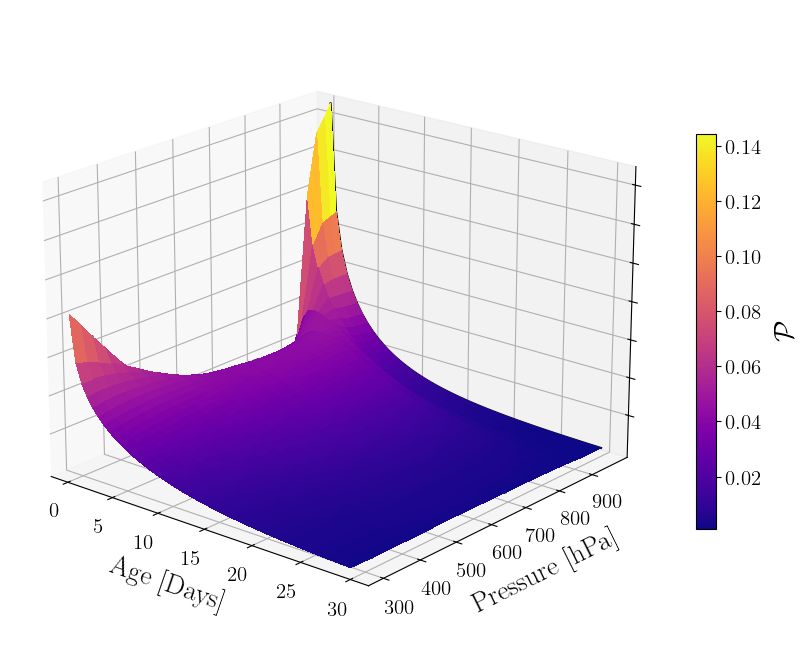

In [11]:
fig, ax = plt.subplots(figsize = (8,8),subplot_kw={"projection": "3d"},constrained_layout=True)

# Make data.
T, P = np.meshgrid(time[:50], pfull[23:])

# Plot the surface.

ax.plot(time[:50],dist_2d[-1,:50], zs=pfull[-1], zdir='y',color = "black")

#ax.set_ylim(1000,275)
ax.set_xlabel("Age [Days]",labelpad = 10,fontsize = 20)
ax.set_ylabel("Pressure [hPa]",labelpad = 10,fontsize = 20)
ax.set_zticklabels([])
ax.view_init(elev=20, azim=-50)
ax.set_ylim(275,994)
fig.savefig(f"{path_cur}/brace/3ddist1.png",dpi = 250,bbox_inches = "tight")

ax.plot(time[:50],dist_2d[-10,:50], zs=pfull[-5], zdir='y',color = "black")
fig.savefig(f"{path_cur}/brace/3ddist2.png",dpi = 250,bbox_inches = "tight")

ax.plot(time[:50],dist_2d[-10,:50], zs=pfull[-10], zdir='y',color = "black")
fig.savefig(f"{path_cur}/brace/3ddist3.png",dpi = 250,bbox_inches = "tight")

ax.plot(time[:50],dist_2d[-20,:50], zs=pfull[-20], zdir='y',color = "black")

fig.savefig(f"{path_cur}/brace/3ddist4.png",dpi = 250,bbox_inches = "tight")


# Make data.
T, P = np.meshgrid(time[:50], pfull[23:])

# Plot the surface.
surf = ax.plot_surface(T, P, dist_2d[23:,:50], cmap="plasma",
                       linewidth=0, antialiased=False)
cbar = plt.colorbar(surf,shrink = 0.5)
cbar.set_label("$\\mathcal{P}$", fontsize=20,labelpad = 10)
fig.savefig(f"{path_cur}/brace/3ddist5.png",dpi = 250,bbox_inches = "tight")


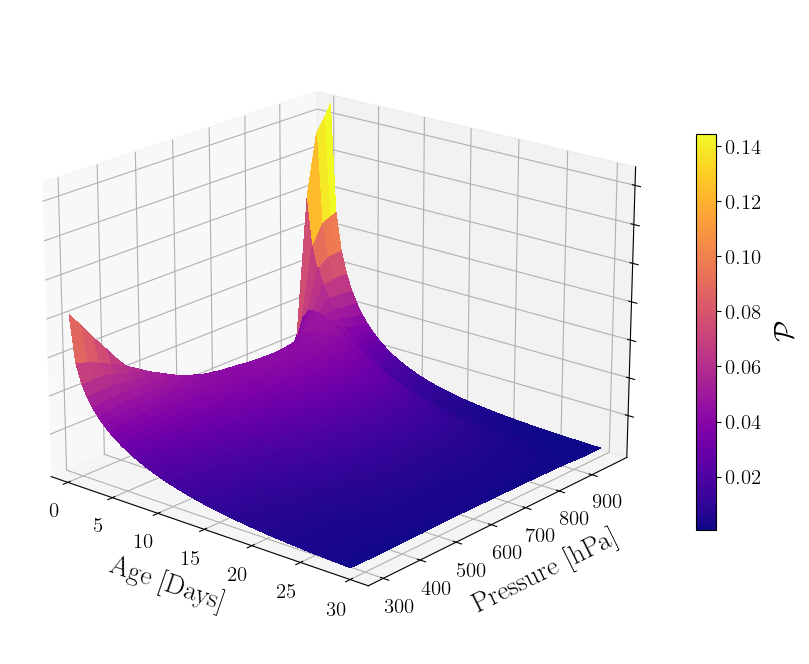

In [12]:
fig, ax = plt.subplots(figsize = (8,8),subplot_kw={"projection": "3d"},constrained_layout=True)

# Make data.
T, P = np.meshgrid(time[:50], pfull[23:])

# Plot the surface.
surf = ax.plot_surface(T, P, dist_2d[23:,:50], cmap="plasma",
                       linewidth=0, antialiased=False)
cbar = plt.colorbar(surf,shrink = 0.5)
cbar.set_label("$\\mathcal{P}$", fontsize=20,labelpad = 10)
#ax.set_ylim(1000,275)
ax.set_xlabel("Age [Days]",labelpad = 10,fontsize = 20)
ax.set_ylabel("Pressure [hPa]",labelpad = 10,fontsize = 20)
ax.set_zticklabels([])
ax.view_init(elev=20, azim=-50)
ax.set_ylim(275,994)
fig.savefig(f"{path_cur}/brace/3ddist.png",dpi = 250,bbox_inches = "tight")

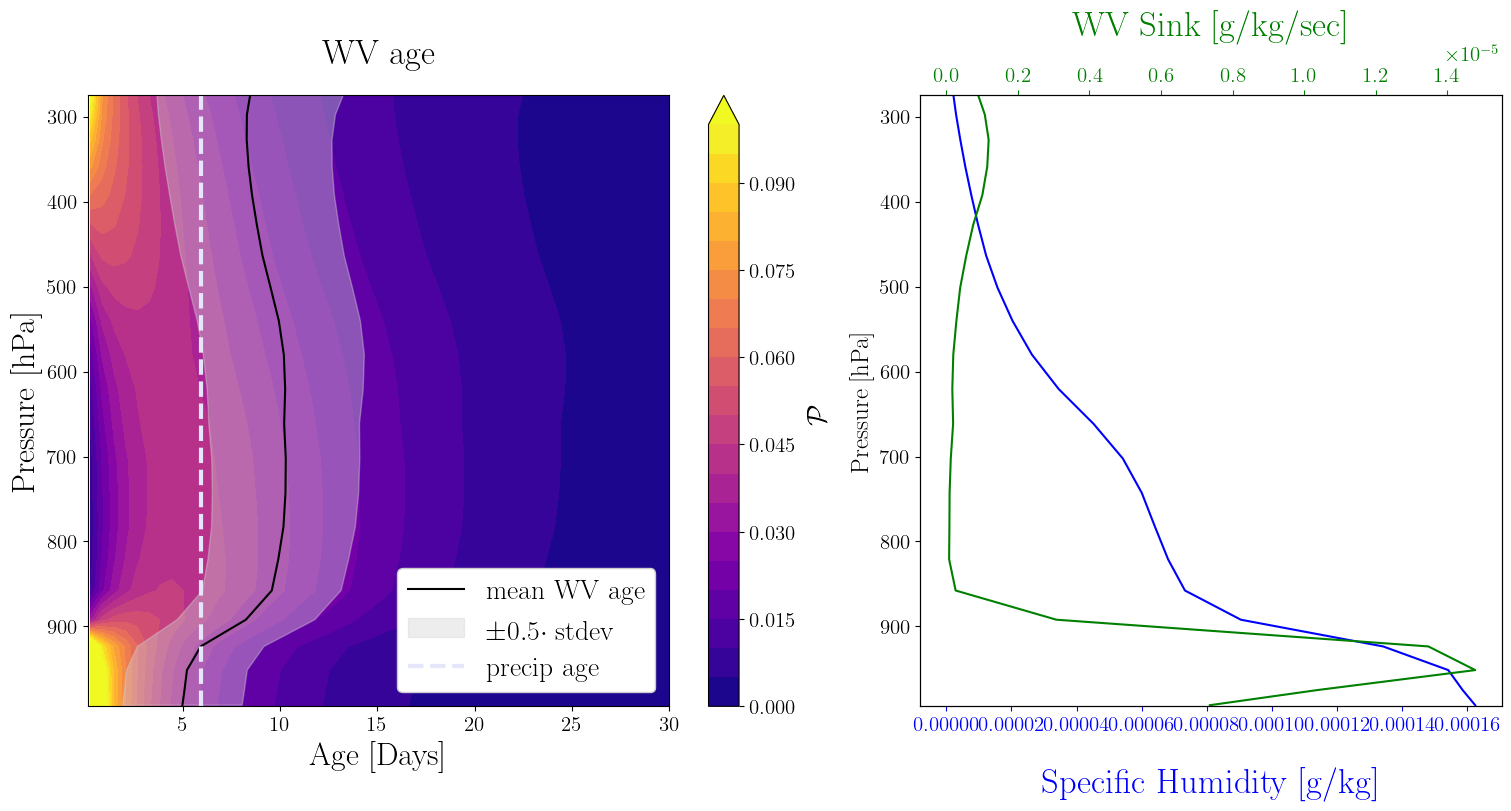

In [13]:
fig,ax = plt.subplots(1,2,figsize = (15,8),constrained_layout=True)

ax[1].set_ylabel("Pressure [hPa]", fontsize=18)
for a in ax:
    a.set_ylim(994,275)
    
ax[0].set_title("WV age",fontsize = 25,pad = 23)
#ax[0].set_xscale("log")
cb = ax[0].contourf(time,pfull,dist_2d, levels = np.linspace(0,0.1,21),extend = "max",cmap = "plasma")
cbar = plt.colorbar(cb)
cbar.set_label("$\\mathcal{P}$", fontsize=20,labelpad = 10)

ax[0].set_xlim(0.1,30)
ax[0].set_xlabel("Age [Days]",fontsize = 23)

ax[1].plot(1e3 * qprofile, pfull, color="blue")
ax[1].set_xlabel("Specific Humidity [g/kg]", color="blue", fontsize=25,labelpad = 23)
ax[0].set_ylabel("Pressure [hPa]", fontsize=23)
ax[1].tick_params(axis="x", colors="blue")
# Add secondary x-axis for WV Sink
ax2 = ax[1].twiny()
ax2.plot(-1e3 * sinkprofile, pfull, color="green")
ax2.set_xlabel("WV Sink [g/kg/sec]", color="green", fontsize=25,labelpad = 23)
ax2.tick_params(axis="x", colors="green")
fig.savefig(f"{path_cur}/brace/profile1.png",dpi = 250,bbox_inches = "tight")
ax[0].plot(profile,pfull,color = "black",label = "mean WV age")
ax[0].fill_betweenx(
    pfull,                      # y-values
    profile - 0.5*profile_std,      # left boundary
    profile + 0.5*profile_std,      # right boundary
    color="lightgrey",               # fill color
    alpha=0.4,                   # transparency
    label = "$\\pm 0.5 \\cdot$ stdev"
)
ax[0].legend(loc= "lower right",fontsize = 20,framealpha = 1)
fig.savefig(f"{path_cur}/brace/profile2.png",dpi = 250,bbox_inches = "tight")
ax[0].axvline(precip_age.values[la,lo]/(24*60**2),color = "lavender",linestyle = "dashed",label = "precip age",linewidth=3)
ax[0].legend(loc= "lower right",fontsize = 20,framealpha = 1)
fig.savefig(f"{path_cur}/brace/profile3.png",dpi = 250,bbox_inches = "tight")

In [14]:
pfull[lo]

974.7763761959532

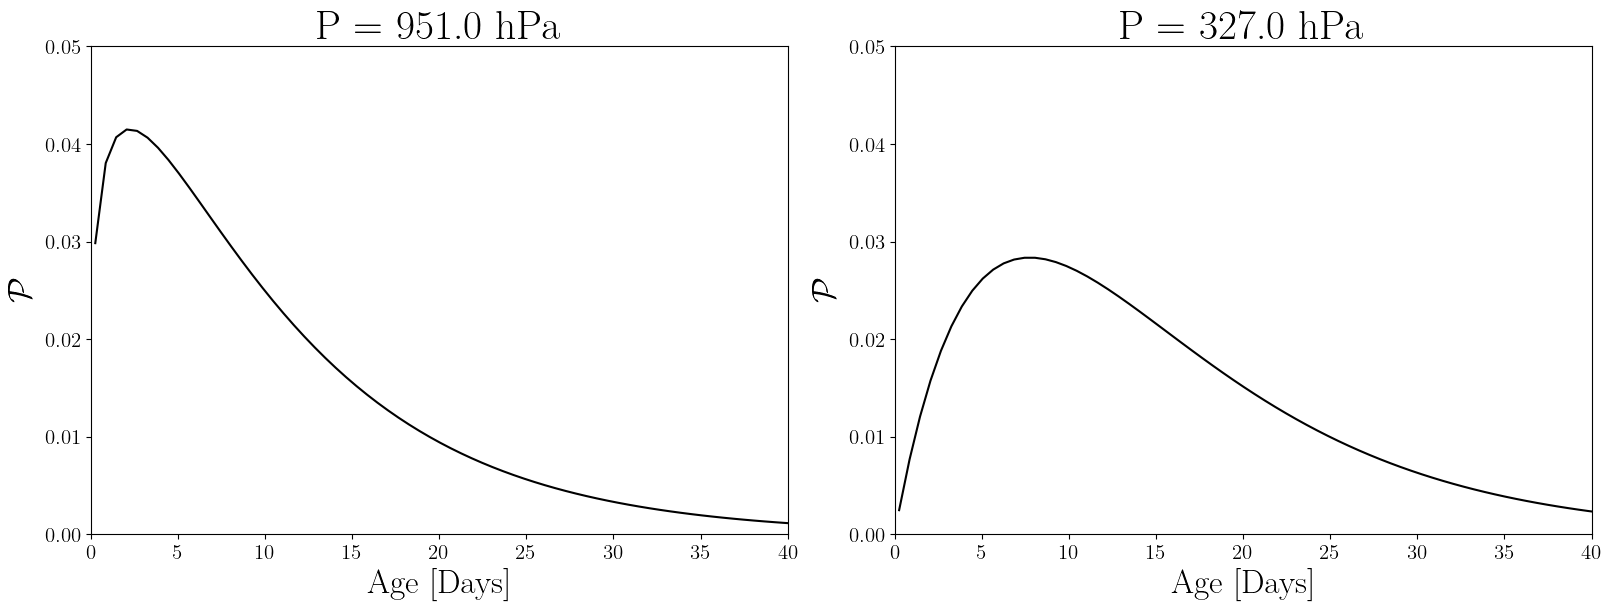

In [15]:
fig,axs = plt.subplots(1,2,figsize = (16,6),constrained_layout=True)
time = np.linspace(0.25,3000,5000)
dt = time[1] - time[0]

for ax in axs:
    ax.set_ylim(0,0.05)
    ax.set_xlim(0,40)
    ax.set_ylabel(r"$\mathcal{P}$",fontsize = 24)
    ax.set_xlabel("Age [Days]",fontsize = 24)

p = -3
axs[0].set_title(f"P = {round(pfull[p],0)} hPa",fontsize = 30)

dist1 = gamma_dist(time,time_mean_age[p,lo,la],time_mom2_age[p,lo,la])
cdf1 = np.cumsum(dist1)*dt
cdf1 /= cdf1[-1] 
idd1 = np.argmin(np.abs(cdf1-0.5))
med1 = np.interp(0.5, cdf1, time)
axs[0].plot(time,dist1,color = "black",linestyle = "solid")

p = -20
axs[1].set_title(f"P = {round(pfull[p],0)} hPa",fontsize = 30)
dist1 = gamma_dist(time,time_mean_age[p,lo,la],time_mom2_age[p,lo,la])
cdf1 = np.cumsum(dist1)*dt
cdf1 /= cdf1[-1] 
idd1 = np.argmin(np.abs(cdf1-0.5))
med1 = np.interp(0.5, cdf1, time)
axs[1].plot(time,dist1,color = "black",linestyle = "solid")

fig.savefig(f"{path_cur}/brace/doo.png",dpi = 250,bbox_inches = "tight")

A
4.845563 0.8380876678160148
9.283615 1.1894117167950078
7.904098 0.9139197809013566
B
5.4876456 0.7385017872296569
9.062114 0.9968209713310663
11.651025 1.2135140585034438
C
10.411162 1.09663636778406
12.405052 1.2803213057134952
14.10682 1.4061546935552083


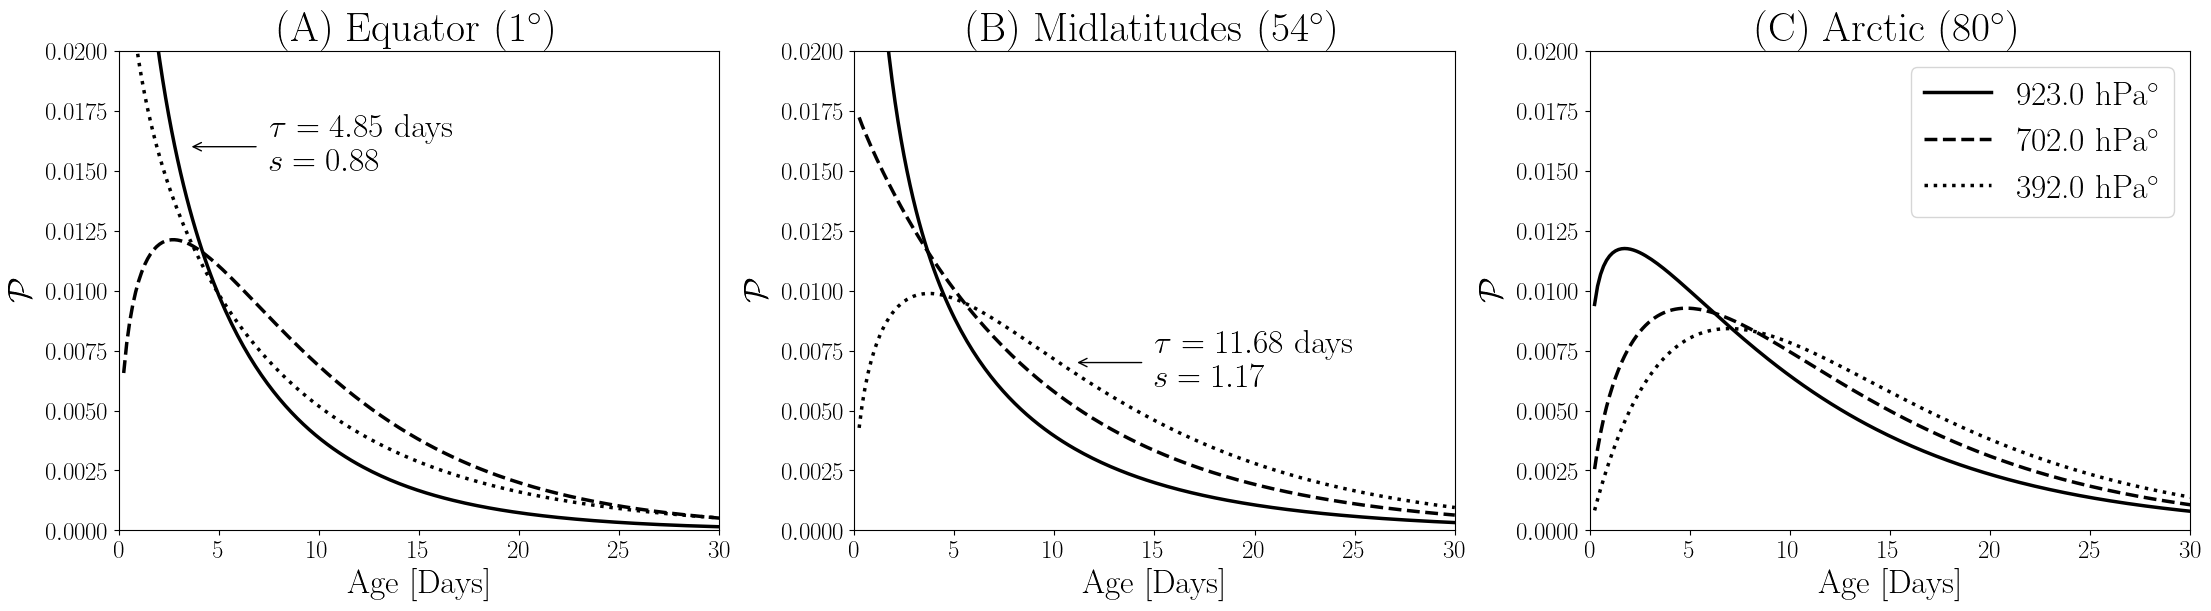

In [16]:

fig,ax = plt.subplots(1,3,figsize = (22,6),constrained_layout=True)
time = np.linspace(0.25,30,200)
print("A")
j = 0
for i in range(3):
    p = pinds[i]
    l = latind[i]
    dist = gamma_dist(time,zonal_moments[0][p][l],zonal_moments[1][p][l])
    ax[0].plot(time,dist,label = f"{round(pfull[p],0)} hPa",color = "black",linestyle = blues[j],linewidth = 2.5)
    ax[0].set_title(r"(A) Equator (1$^{\circ}$)",fontsize = 30)
    print(zonal_moments[0][p][l], zonal_moments[0][p][l]/np.sqrt(zonal_moments[1][p][l]-zonal_moments[0][p][l]**2))
    j+=1
print("B")    
for i in range(3,6,1):
    p = pinds[i]
    l = latind[i]
    dist = gamma_dist(time,zonal_moments[0][p][l],zonal_moments[1][p][l])
    ax[1].plot(time,dist,label = f"{round(pfull[p],0)} hPa",color = "black",linestyle = blues[j],linewidth = 2.5)
    ax[1].set_title(r"(B) Midlatitudes (54$^{\circ}$)",fontsize = 30)
    print(zonal_moments[0][p][l], zonal_moments[0][p][l]/np.sqrt(zonal_moments[1][p][l]-zonal_moments[0][p][l]**2))
    j+=1
    
print("C")      
for i in range(6,9,1):
    p = pinds[i]
    l = latind[i]
    dist = gamma_dist(time,zonal_moments[0][p][l],zonal_moments[1][p][l])
    ax[2].plot(time,dist,label = f"{round(pfull[p],0)} hPa" + r"$^{\circ}$",color = "black",linestyle = blues[j],linewidth = 2.5)
    ax[2].set_title(r"(C) Arctic (80$^{\circ}$)",fontsize = 30)
    print(zonal_moments[0][p][l], zonal_moments[0][p][l]/np.sqrt(zonal_moments[1][p][l]-zonal_moments[0][p][l]**2))
    j+=1
    
ax[0].set_ylabel(r"$\mathcal{P}$",fontsize = 24)

for i in range(3):
    ax[i].set_ylim(0,0.02)
    ax[i].set_xlim(0,30)
    ax[i].set_xlabel("Age [Days]",fontsize = 24)
    ax[i].tick_params(axis='x', labelsize=18)  # Change font size for x-axis tick labels
    ax[i].tick_params(axis='y', labelsize=18)
    ax[i].set_ylabel(r"$\mathcal{P}$",fontsize = 24)
    ax[i].set_xlabel("Age [Days]",fontsize = 24)
ax[2].legend(fontsize = 24)

ax[0].annotate("", xytext=(7, 0.016), xy=(3.5, 0.016),arrowprops=dict(arrowstyle="->"))
ax[0].text(7.5,0.015,"$\\tau = 4.85$ days \n $s = 0.88$",fontsize = 24)

ax[1].annotate("", xytext=(14.5, 0.007), xy=(11, 0.007),arrowprops=dict(arrowstyle="->"))
ax[1].text(15,0.006,"$\\tau = 11.68$ days \n $s = 1.17$",fontsize = 24)

fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.savefig(f"{path_cur}/sample_distribution.png",dpi = 250,bbox_inches = "tight")

First, we want to show that the moments can be predicted using the Weibull and Gamma

In [17]:
a,b = get_a_b(zonal_moments[0],zonal_moments[1])
alpha, theta  = get_alpha_theta(mean_age.values,mom2_age.values)

gamma_moments = get_n_moment_gamma(alpha,theta)
weibull_moments = []

for i in range(5):
    print(i+1)
    weibull_moments.append(get_n_moment_weib(a,b,i+1))

gamma_moments = np.array(gamma_moments)
zonal_gamma_moments = np.mean(np.mean(gamma_moments,axis = 4),axis = 1)/ np.array([seconds_per_day,seconds_per_day**2,seconds_per_day**3])[:,np.newaxis,np.newaxis]


weibull_moments = np.array(weibull_moments)

std_model = np.sqrt(zonal_moments[1] - zonal_moments[0]**2)
std_gamma = np.sqrt(zonal_gamma_moments[1] - zonal_gamma_moments[0]**2)
std_weibull = np.sqrt(weibull_moments[1] - weibull_moments[0]**2)


def skewness_from_moments(mu1, mu2, mu3):
    variance = mu2 - mu1**2
    std = np.sqrt(variance)
    skew = (mu3 - 3*mu1*variance - mu1**3) / (std**3)
    return skew

skew_model = skewness_from_moments(zonal_moments[0], zonal_moments[1], zonal_moments[2])
skew_gamma = np.mean(np.mean(skewness_from_moments(gamma_moments[0], gamma_moments[1], gamma_moments[2]),axis = 3),axis =0)
print(skew_gamma.shape)
skew_weibull = skewness_from_moments(weibull_moments[0], weibull_moments[1], weibull_moments[2])


1
2
3
4
5


IndexError: index 2 is out of bounds for axis 0 with size 2

TypeError: plot_vertical_profile() missing 1 required positional argument: 'mask'

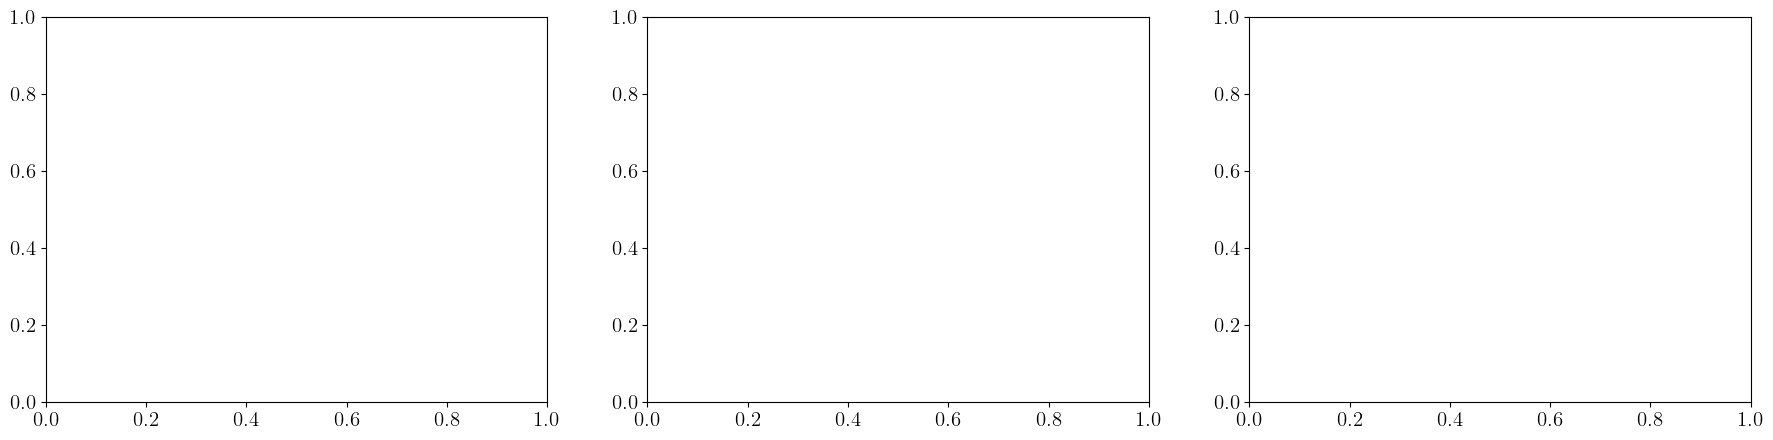

In [ ]:
fig, ax = plt.subplots(1,3,figsize = (22,5))

ax_age = ax[0]
dps.plot_vertical_profile(zonal_moments[0] - zonal_gamma_moments[0],lat,pfull,ax_age,"PRGn",level_space=np.linspace(-3e-6,3e-6,25),contours=False,lnP = False,
                      theta = False,thetac="",pot_temp_zonal=None,extend = "both")
ax_age.set_title(r"mean",fontsize = 30,pad = 10)
ax_age = ax[1]
dps.plot_vertical_profile(std_model - std_gamma,lat,pfull,ax_age,"PRGn",level_space=np.linspace(-3e-6,3e-6,25),contours=False,lnP = False,
                      theta = False,thetac="",pot_temp_zonal=None,extend = "both")
ax_age.set_ylabel(" ")
ax_age.set_title(r"std",fontsize = 30,pad = 10)
ax_age = ax[2]
dps.plot_vertical_profile(skew_model - skew_gamma,lat,pfull,ax_age,"PRGn",level_space=np.linspace(-10,10,25),contours=False,lnP = False,
                      theta = False,thetac="",pot_temp_zonal=None,extend = "both")
ax_age.set_ylabel(" ")

ax_age.set_title(r"skew",fontsize = 30,pad = 10)
for axi in ax:
    axi.set_xlabel("Latitude [deg]")
    
fig.suptitle("Difference Between the Model and Gamma Distribution",y = 1.1,fontsize = 30)
plt.savefig(f"{path_cur}/comp_mean_std_skew_gamma.png",dpi = 250,bbox_inches = "tight")

NameError: name 'skew_model' is not defined

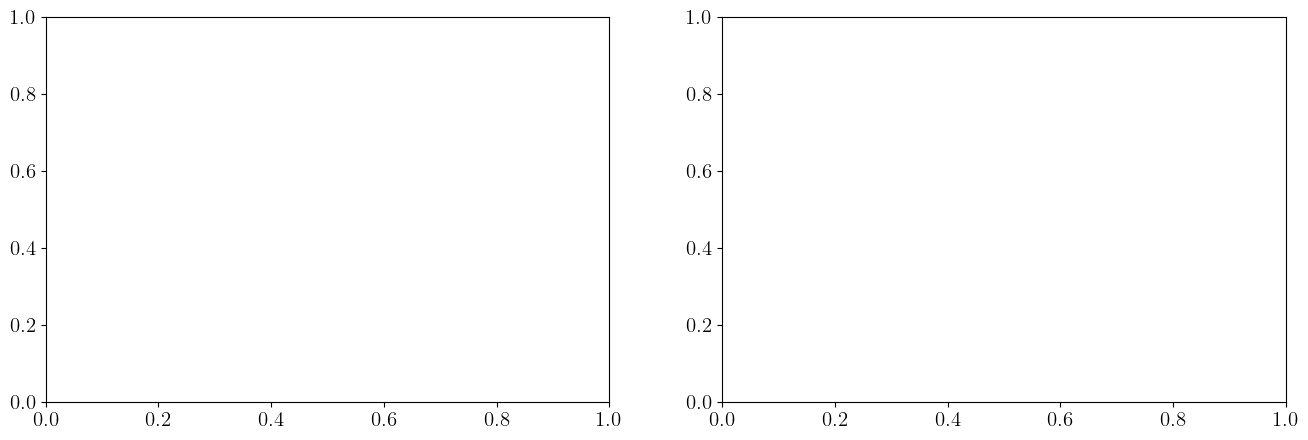

In [ ]:
fig, ax = plt.subplots(1,2,figsize = (16,5))

ax_age = ax[0]
dps.plot_vertical_profile(skew_model,lat,pfull,ax_age,"YlGnBu",level_space=np.linspace(0,15,41),contours=False,lnP = False,
                      theta = False,thetac="",pot_temp_zonal=None,extend = "max")
ax_age.set_title(r"Model",fontsize = 30,pad = 10)
ax_age = ax[1]
dps.plot_vertical_profile(skew_gamma,lat,pfull,ax_age,"YlGnBu",level_space=np.linspace(0,4,41),contours=False,lnP = False,
                      theta = False,thetac="",pot_temp_zonal=None,extend = "max")
ax_age.set_ylabel(" ")

ax_age.set_title(r"Gamma",fontsize = 30,pad = 10)
for axi in ax:
    axi.set_xlabel("Latitude [deg]")
    
fig.suptitle("Skewness calculated from the model output vs the gamma fct",y = 1.1,fontsize = 30)
plt.savefig(f"{path_cur}/skew_gamma.png",dpi = 250,bbox_inches = "tight")